# Interactive Video Crop Adjustment

This notebook helps you adjust cropping parameters for surgical video footage. Use the interactive sliders to remove black borders and bottom bars from your videos.

## 1. Import Required Libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
from ipywidgets import interact, IntSlider, VBox, HBox, Button, Output, Text
from IPython.display import display, clear_output

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Display Video

Specify the path to your input video file.

Video Properties:
  Resolution: 1920x1080
  FPS: 30.0
  Total Frames: 900
  Duration: 30.00 seconds


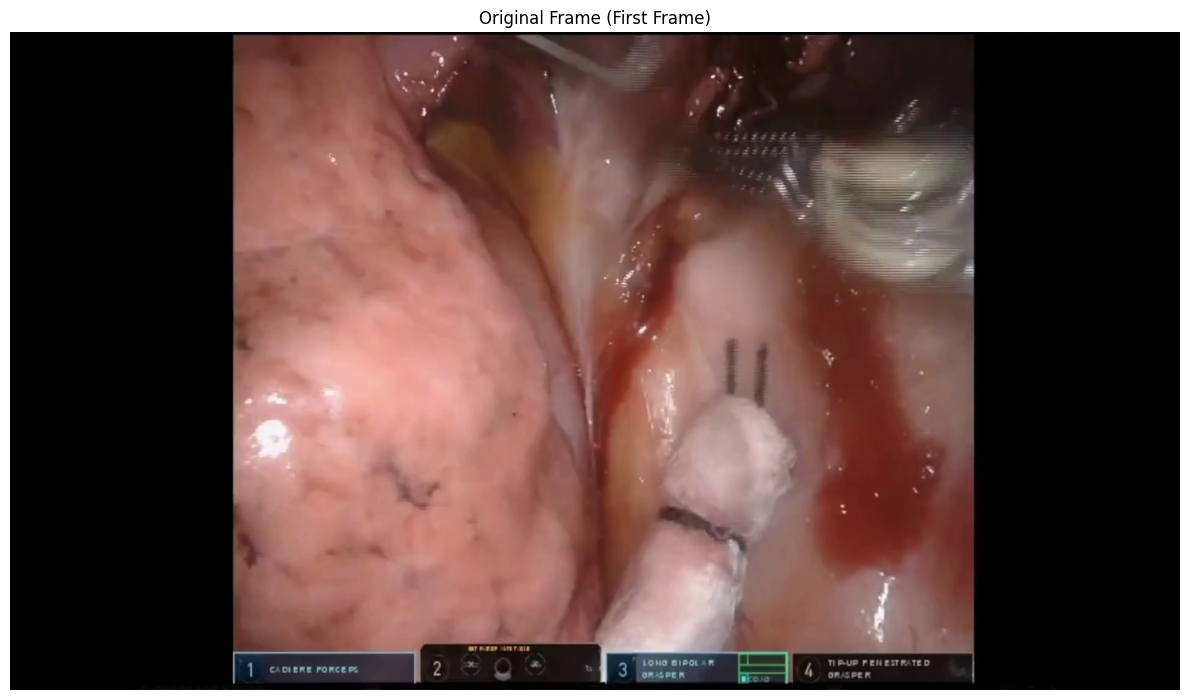

In [3]:
# Specify your video path here
video_path = r"C:\Users\Skyfinder\Projects\SurgeNetSeg\custom\data\output_clips\s8-s10_LLL_001800_002700.mp4"  # Update this path

# Load video
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f"Error: Could not open video at {video_path}")
else:
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Read the first frame for preview
    ret, original_frame = cap.read()
    
    if ret:
        # Convert BGR to RGB for matplotlib
        original_frame = cv2.cvtColor(original_frame, cv2.COLOR_BGR2RGB)
        
        print(f"Video Properties:")
        print(f"  Resolution: {width}x{height}")
        print(f"  FPS: {fps}")
        print(f"  Total Frames: {frame_count}")
        print(f"  Duration: {frame_count/fps:.2f} seconds")
        
        # Display original frame
        plt.figure(figsize=(12, 8))
        plt.imshow(original_frame)
        plt.title("Original Frame (First Frame)")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("Error: Could not read first frame")
    
    cap.release()

## 3. Interactive Crop Adjustment

Use the sliders below to adjust the crop values. The values represent how many pixels to remove from each side of the frame.

In [4]:
# Global variables for crop values
crop_params = {
    'left': 85,
    'right': 85,
    'top': 0,
    'bottom': 60
}

# Create interactive sliders
left_slider = IntSlider(min=0, max=width//2, step=1, value=0, description='Left:')
right_slider = IntSlider(min=0, max=width//2, step=1, value=0, description='Right:')
top_slider = IntSlider(min=0, max=height//2, step=1, value=0, description='Top:')
bottom_slider = IntSlider(min=0, max=height//2, step=1, value=0, description='Bottom:')

def update_crop(left, right, top, bottom):
    """Update the cropped frame preview"""
    crop_params['left'] = left
    crop_params['right'] = right
    crop_params['top'] = top
    crop_params['bottom'] = bottom
    
    # Calculate new dimensions
    new_width = width - left - right
    new_height = height - top - bottom
    
    # Crop the frame
    cropped = original_frame[top:height-bottom, left:width-right]
    
    # Display side-by-side comparison
    fig, axes = plt.subplots(2, 1, figsize=(16, 32))
    
    # Original with crop area marked
    axes[0].imshow(original_frame)
    axes[0].axvline(x=left, color='r', linestyle='--', linewidth=2)
    axes[0].axvline(x=width-right, color='r', linestyle='--', linewidth=2)
    axes[0].axhline(y=top, color='r', linestyle='--', linewidth=2)
    axes[0].axhline(y=height-bottom, color='r', linestyle='--', linewidth=2)
    axes[0].set_title(f'Original ({width}x{height})')
    axes[0].axis('off')
    
    # Cropped
    axes[1].imshow(cropped)
    axes[1].set_title(f'Cropped ({new_width}x{new_height})')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Crop Settings:")
    print(f"  Left: {left}px, Right: {right}px, Top: {top}px, Bottom: {bottom}px")
    print(f"  New Resolution: {new_width}x{new_height}")

# Create interactive widget
interact(update_crop, 
         left=left_slider, 
         right=right_slider, 
         top=top_slider, 
         bottom=bottom_slider);

interactive(children=(IntSlider(value=0, description='Left:', max=960), IntSlider(value=0, description='Right:…

## 4. Save Crop Parameters

Save your crop settings to a JSON file for use in batch processing.

In [ ]:
# Save crop parameters to JSON (per original filename)
config_path = "crop_config.json"
video_name = Path(video_path).stem  # Use full filename without extension
try:
    with open(config_path, 'r') as f:
        all_configs = json.load(f)
except (FileNotFoundError, json.JSONDecodeError):
    all_configs = {}
if 'videos' not in all_configs:
    all_configs['videos'] = {}
# Find matching config by filename
found = False
for key in all_configs['videos']:
    if key in video_name:
        video_prefix = key
        found = True
        all_configs['videos'][video_prefix] = {
            "crop_params": crop_params,
            "original_resolution": {"width": width, "height": height},
            "new_resolution": {
                "width": width - crop_params['left'] - crop_params['right'],
                "height": height - crop_params['top'] - crop_params['bottom']
            },
            "video_prefix": video_prefix
        }
        with open(config_path, 'w') as f:
            json.dump(all_configs, f, indent=4)
        print(f"✓ Crop parameters for {video_prefix} saved to {config_path}")
        print(json.dumps(all_configs['videos'][video_prefix], indent=2))
        break
if not found:
    print(f"Crop config not found for {video_prefix}. Please prime crop_config.json first.")

✓ Crop parameters for s8-s10_LLL saved to crop_config.json
{
  "crop_params": {
    "left": 367,
    "right": 339,
    "top": 0,
    "bottom": 76
  },
  "original_resolution": {
    "width": 1920,
    "height": 1080
  },
  "new_resolution": {
    "width": 1214,
    "height": 1004
  },
  "video_prefix": "s8-s10_LLL"
}


## 5. Test Multiple Frames

Preview the crop on multiple frames from different parts of the video to ensure consistency.

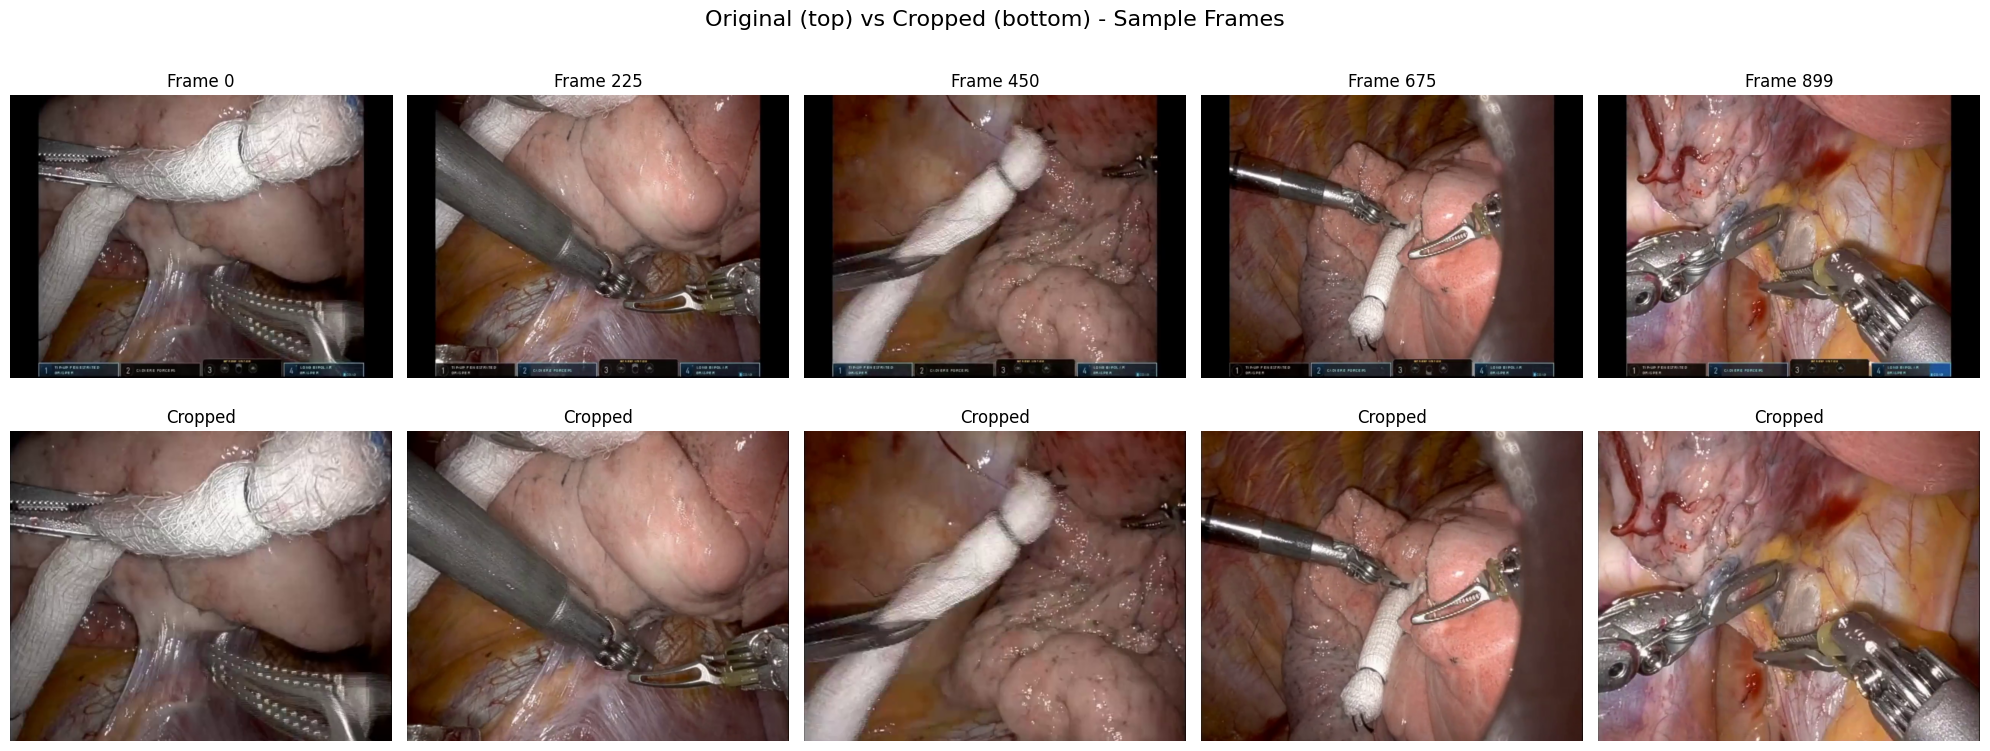

✓ Crop parameters look consistent across all sampled frames!


In [14]:
# Test crop on multiple frames
cap = cv2.VideoCapture(video_path)

# Select frames at different positions: start, 25%, 50%, 75%, end
frame_positions = [0, int(frame_count * 0.25), int(frame_count * 0.5), 
                   int(frame_count * 0.75), frame_count - 1]

fig, axes = plt.subplots(2, len(frame_positions), figsize=(20, 8))

for idx, frame_pos in enumerate(frame_positions):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_pos)
    ret, frame = cap.read()
    
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Original
        axes[0, idx].imshow(frame_rgb)
        axes[0, idx].set_title(f'Frame {frame_pos}')
        axes[0, idx].axis('off')
        
        # Cropped
        cropped = frame_rgb[crop_params['top']:height-crop_params['bottom'], 
                           crop_params['left']:width-crop_params['right']]
        axes[1, idx].imshow(cropped)
        axes[1, idx].set_title(f'Cropped')
        axes[1, idx].axis('off')

cap.release()
plt.suptitle('Original (top) vs Cropped (bottom) - Sample Frames', fontsize=16)
plt.tight_layout()
plt.show()

print("✓ Crop parameters look consistent across all sampled frames!")